# Stochastic Methods for Derivative Pricing — Full Analysis

A framework comparing analytical (Black-Scholes) vs Monte Carlo derivative
pricing, with variance reduction, path-dependent exotics (Asian, Barrier),
and Heston stochastic volatility.

**Base parameters:** `S0=100, K=110, T=1, r=0.05, sigma=0.20` (barriers at
`B_up=130`, `B_down=80`).

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))
os.makedirs('../outputs', exist_ok=True)

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import qmc, norm

from src.black_scholes import bs_price, bs_greeks, put_call_parity_check
from src.monte_carlo import simulate_terminal_prices, simulate_paths, mc_price, convergence_study
from src.greeks import (greeks_comparison_table, mc_delta_gamma, mc_vega,
                         mc_theta, mc_rho, bump_stability_study)
from src.variance_reduction import (mc_price_crude, mc_price_antithetic,
                                     mc_price_control_variate, mc_price_sobol,
                                     efficiency_table)
from src.exotics import (asian_arithmetic_mc, asian_geometric_mc,
                          asian_geometric_closed_form, barrier_option_mc,
                          barrier_parity_check)
from src.heston import simulate_heston_paths, heston_mc_price, implied_vol, implied_vol_smile


plt.rcParams['figure.dpi'] = 110

S0, K, T, r, sigma = 100, 110, 1.0, 0.05, 0.20
N_PATHS = 200_000
N_STEPS = 252
B_up, B_down = 130, 80

## Phase 1 — Black-Scholes vs Monte Carlo
Foundation: validates the MC engine against the closed-form analytical price.

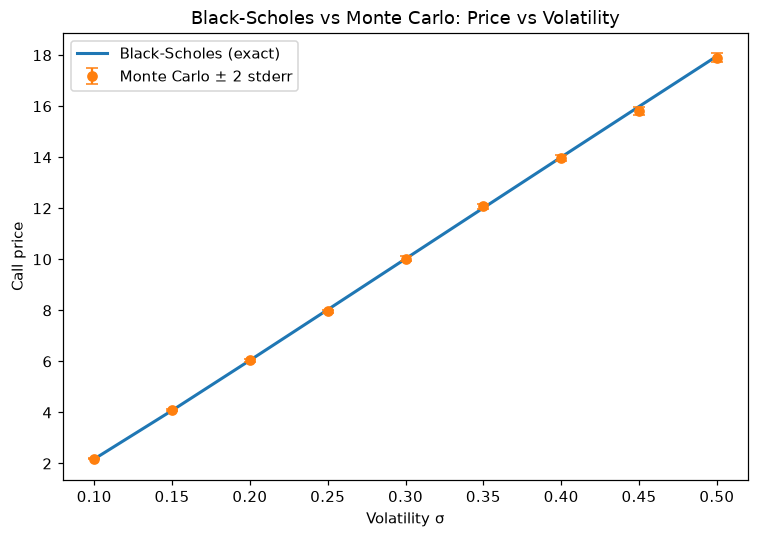

In [2]:
# Plot 1 — BS vs MC price across volatilities
sigmas = np.linspace(0.1, 0.5, 9)
bs_prices = [bs_price(S0, K, T, r, s) for s in sigmas]
mc_prices, mc_errs = [], []
for i, s in enumerate(sigmas):
    p, se = mc_price(S0, K, T, r, s, n_paths=N_PATHS, seed=100 + i)
    mc_prices.append(p); mc_errs.append(se)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(sigmas, bs_prices, label="Black-Scholes (exact)", lw=2)
ax.errorbar(sigmas, mc_prices, yerr=[2*e for e in mc_errs], fmt="o",
            label="Monte Carlo ± 2 stderr", capsize=4)
ax.set_xlabel("Volatility σ"); ax.set_ylabel("Call price")
ax.set_title("Black-Scholes vs Monte Carlo: Price vs Volatility")
ax.legend(); fig.tight_layout()
fig.savefig("../outputs/01_bs_vs_mc_price.png", dpi=130)
plt.show()

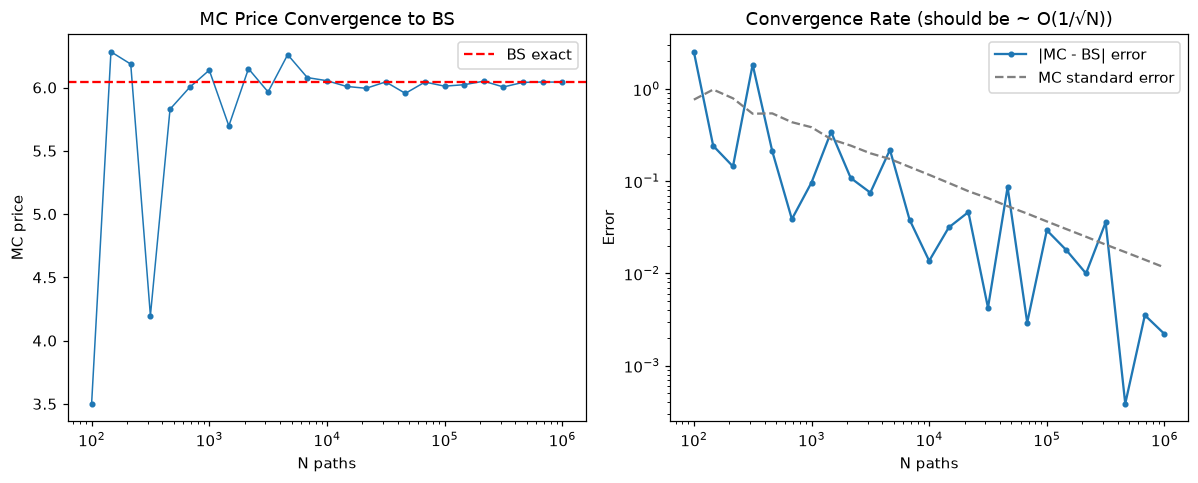

In [3]:
# Plot 2 — MC convergence to BS
n_list = np.unique(np.logspace(2, 6, 25).astype(int))
results = convergence_study(S0, K, T, r, 0.20, n_list, seed=7)
Ns = [x[0] for x in results]; prices = [x[1] for x in results]
errs = [abs(x[1] - bs_price(S0, K, T, r, 0.20)) for x in results]
ses = [x[2] for x in results]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(Ns, prices, marker=".", lw=1)
axes[0].axhline(bs_price(S0, K, T, r, 0.20), color="red", ls="--", label="BS exact")
axes[0].set_xscale("log"); axes[0].set_xlabel("N paths"); axes[0].set_ylabel("MC price")
axes[0].set_title("MC Price Convergence to BS"); axes[0].legend()

axes[1].loglog(Ns, errs, marker=".", label="|MC - BS| error")
axes[1].loglog(Ns, ses, ls="--", color="gray", label="MC standard error")
axes[1].set_xlabel("N paths"); axes[1].set_ylabel("Error")
axes[1].set_title("Convergence Rate (should be ~ O(1/√N))"); axes[1].legend()
fig.tight_layout()
fig.savefig("../outputs/02_mc_convergence.png", dpi=130)
plt.show()

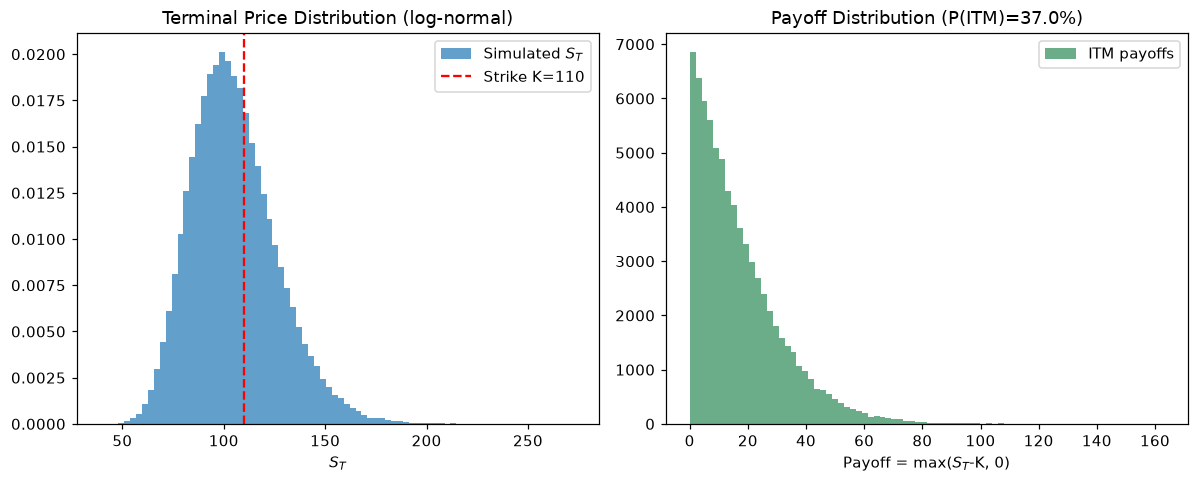

In [4]:
# Plot 3 — terminal price & payoff distributions
S_T = simulate_terminal_prices(S0, r, 0.20, T, N_PATHS, seed=11)
payoffs = np.maximum(S_T - K, 0.0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].hist(S_T, bins=80, density=True, alpha=0.7, label="Simulated $S_T$")
axes[0].axvline(K, color="red", ls="--", label=f"Strike K={K}")
axes[0].set_xlabel("$S_T$"); axes[0].set_title("Terminal Price Distribution (log-normal)")
axes[0].legend()

axes[1].hist(payoffs[payoffs > 0], bins=80, color="seagreen", alpha=0.7, label="ITM payoffs")
axes[1].set_xlabel("Payoff = max($S_T$-K, 0)")
axes[1].set_title(f"Payoff Distribution (P(ITM)={np.mean(S_T > K):.1%})")
axes[1].legend(); fig.tight_layout()
fig.savefig("../outputs/03_distributions.png", dpi=130)
plt.show()

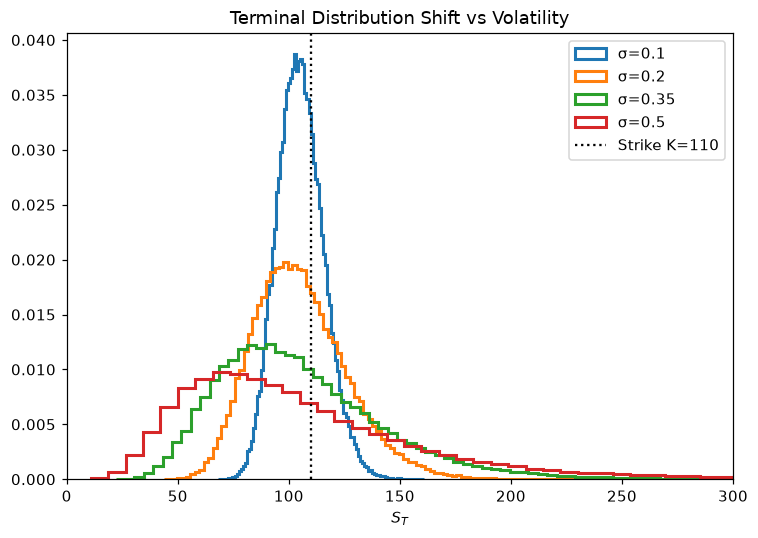

BS @ sigma=0.2: 6.0401
MC @ sigma=0.2: 6.063


In [5]:
# Plot 4 — volatility sensitivity of terminal distribution
fig, ax = plt.subplots(figsize=(7, 5))
for s in [0.10, 0.20, 0.35, 0.50]:
    S_T_s = simulate_terminal_prices(S0, r, s, T, 100_000, seed=21)
    ax.hist(S_T_s, bins=100, density=True, histtype="step", lw=2, label=f"σ={s}")
ax.axvline(K, color="black", ls=":", label=f"Strike K={K}")
ax.set_xlim(0, 300); ax.set_xlabel("$S_T$")
ax.set_title("Terminal Distribution Shift vs Volatility"); ax.legend()
fig.tight_layout()
fig.savefig("../outputs/04_volatility_sensitivity.png", dpi=130)
plt.show()

print("BS @ sigma=0.2:", round(bs_price(S0, K, T, r, 0.20), 4))
print("MC @ sigma=0.2:", round(mc_price(S0, K, T, r, 0.20, N_PATHS, seed=42)[0], 4))

## Phase 2 — Greeks via Finite Differences
Bump-and-reprice Greeks from the MC engine, validated against closed-form Black-Scholes.

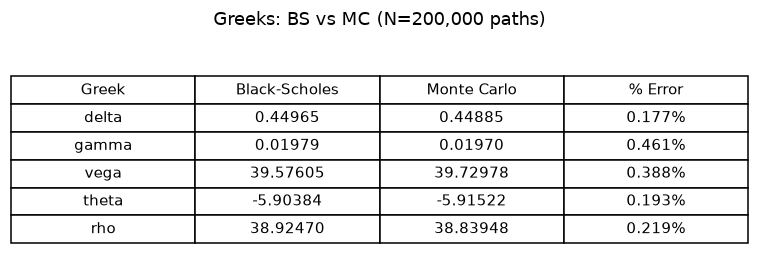

  delta  BS=0.44965 MC=0.44885 err=0.177%
  gamma  BS=0.01979 MC=0.01970 err=0.461%
  vega   BS=39.57605 MC=39.72978 err=0.388%
  theta  BS=-5.90384 MC=-5.91522 err=0.193%
  rho    BS=38.92470 MC=38.83948 err=0.219%


In [6]:
# Plot 5 — Greeks comparison table
table = greeks_comparison_table(S0, K, T, r, sigma, N_PATHS)
fig, ax = plt.subplots(figsize=(7, 2.6)); ax.axis("off")
rows = [[g, f"{bsv:.5f}", f"{mcv:.5f}", f"{err:.3f}%"] for g, (bsv, mcv, err) in table.items()]
tbl = ax.table(cellText=rows, colLabels=["Greek", "Black-Scholes", "Monte Carlo", "% Error"],
               loc="center", cellLoc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1, 1.6)
ax.set_title(f"Greeks: BS vs MC (N={N_PATHS:,} paths)", pad=20)
fig.tight_layout()
fig.savefig("../outputs/05_greeks_table.png", dpi=130)
plt.show()
for g, (bsv, mcv, err) in table.items():
    print(f"  {g:6s} BS={bsv:.5f} MC={mcv:.5f} err={err:.3f}%")

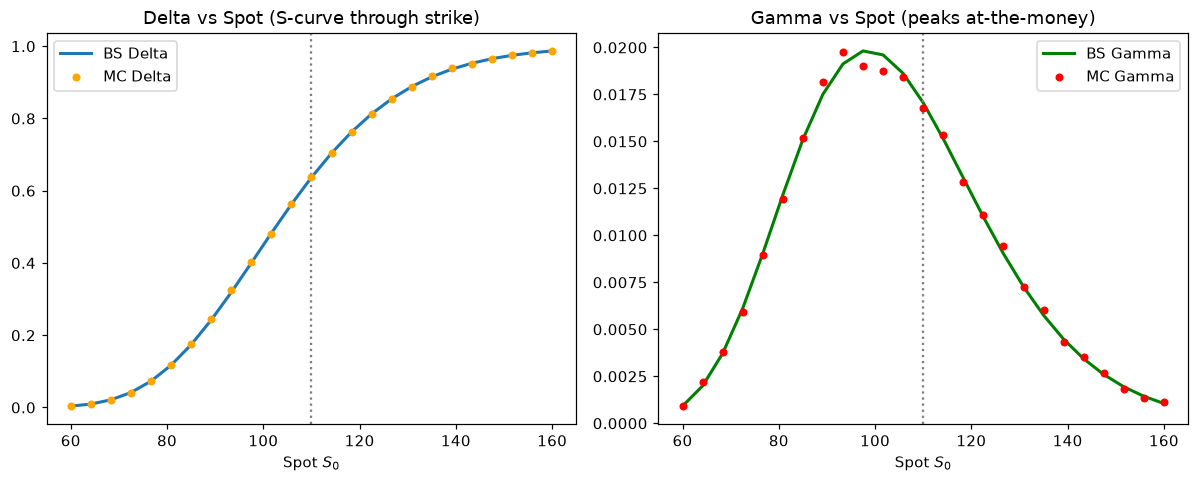

In [7]:
# Plot 6 — Delta & Gamma profiles across spot
S_range = np.linspace(60, 160, 25)
deltas_bs, gammas_bs, deltas_mc, gammas_mc = [], [], [], []
for i, S in enumerate(S_range):
    g = bs_greeks(S, K, T, r, sigma)
    deltas_bs.append(g["delta"]); gammas_bs.append(g["gamma"])
    d, gm = mc_delta_gamma(S, K, T, r, sigma, 60_000, seed=200 + i)
    deltas_mc.append(d); gammas_mc.append(gm)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(S_range, deltas_bs, lw=2, label="BS Delta")
axes[0].scatter(S_range, deltas_mc, s=18, color="orange", label="MC Delta", zorder=3)
axes[0].axvline(K, ls=":", color="gray")
axes[0].set_xlabel("Spot $S_0$"); axes[0].set_title("Delta vs Spot (S-curve through strike)")
axes[0].legend()

axes[1].plot(S_range, gammas_bs, lw=2, color="green", label="BS Gamma")
axes[1].scatter(S_range, gammas_mc, s=18, color="red", label="MC Gamma", zorder=3)
axes[1].axvline(K, ls=":", color="gray")
axes[1].set_xlabel("Spot $S_0$"); axes[1].set_title("Gamma vs Spot (peaks at-the-money)")
axes[1].legend(); fig.tight_layout()
fig.savefig("../outputs/06_delta_gamma_profiles.png", dpi=130)
plt.show()

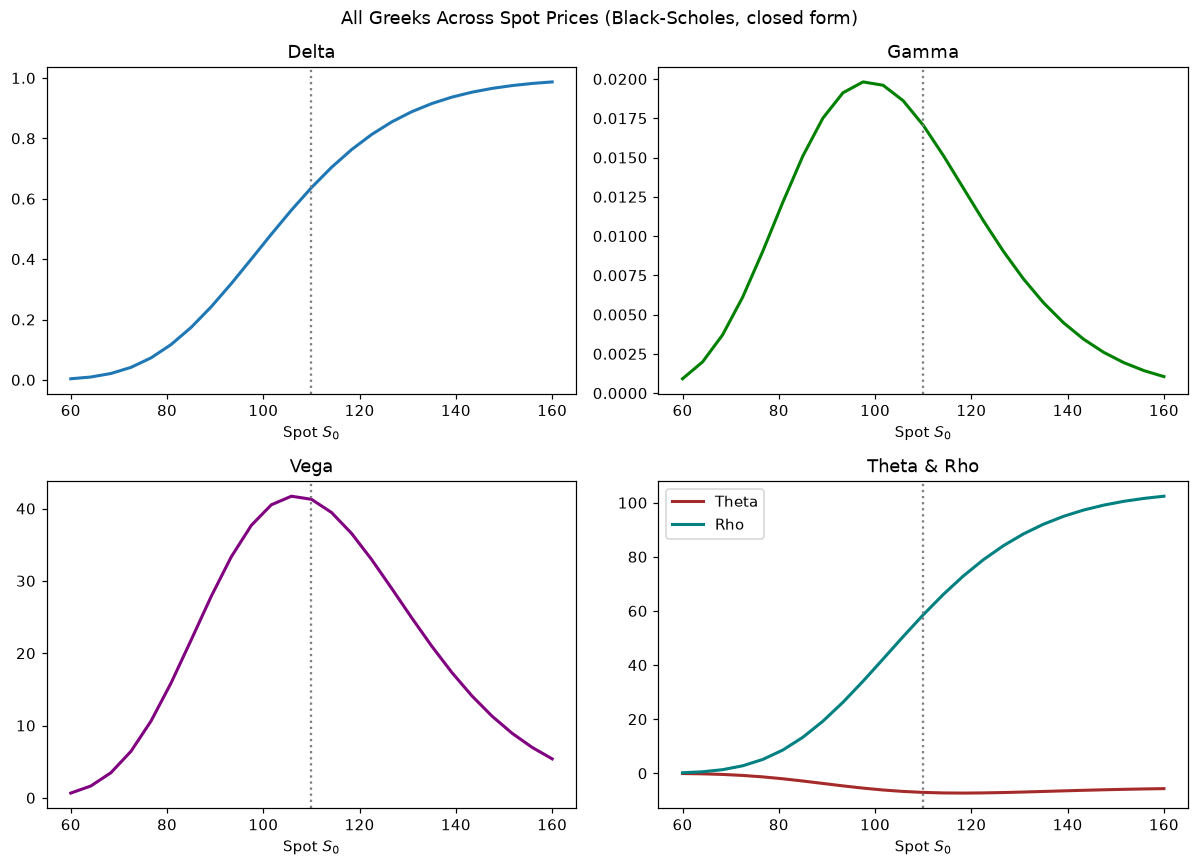

In [8]:
# Plot 7 — all Greeks across spot
vegas_bs, thetas_bs, rhos_bs = [], [], []
for S in S_range:
    g = bs_greeks(S, K, T, r, sigma)
    vegas_bs.append(g["vega"]); thetas_bs.append(g["theta"]); rhos_bs.append(g["rho"])

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes[0,0].plot(S_range, deltas_bs, lw=2); axes[0,0].set_title("Delta")
axes[0,1].plot(S_range, gammas_bs, lw=2, color="green"); axes[0,1].set_title("Gamma")
axes[1,0].plot(S_range, vegas_bs, lw=2, color="purple"); axes[1,0].set_title("Vega")
axes[1,1].plot(S_range, thetas_bs, lw=2, color="brown", label="Theta")
axes[1,1].plot(S_range, rhos_bs, lw=2, color="teal", label="Rho")
axes[1,1].legend(); axes[1,1].set_title("Theta & Rho")
for a in axes.flat:
    a.axvline(K, ls=":", color="gray"); a.set_xlabel("Spot $S_0$")
fig.suptitle("All Greeks Across Spot Prices (Black-Scholes, closed form)")
fig.tight_layout()
fig.savefig("../outputs/07_all_greeks_profile.png", dpi=130)
plt.show()

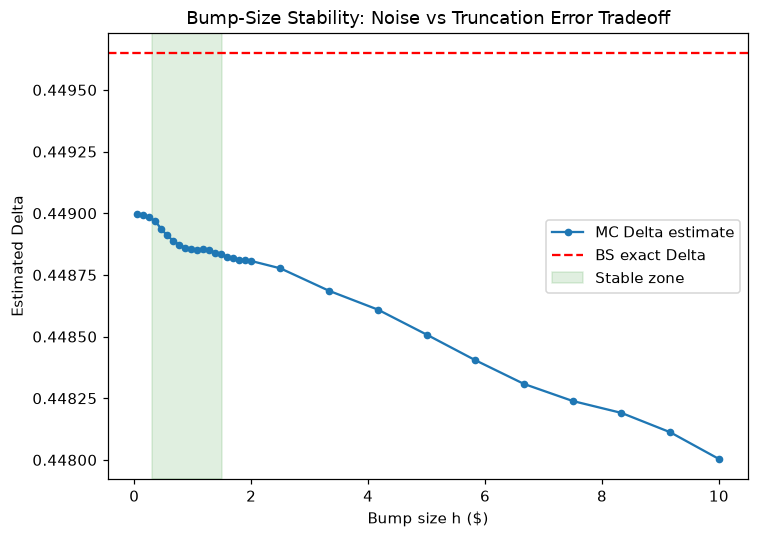

In [9]:
# Plot 8 — bump-size stability study
results = bump_stability_study(S0, K, T, r, sigma, N_PATHS, seed=42)
hs = [x[0] for x in results]; deltas_h = [x[1] for x in results]
true_delta = bs_greeks(S0, K, T, r, sigma)["delta"]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(hs, deltas_h, marker="o", ms=4, label="MC Delta estimate")
ax.axhline(true_delta, color="red", ls="--", label="BS exact Delta")
ax.axvspan(0.3, 1.5, color="green", alpha=0.12, label="Stable zone")
ax.set_xlabel("Bump size h ($)"); ax.set_ylabel("Estimated Delta")
ax.set_title("Bump-Size Stability: Noise vs Truncation Error Tradeoff")
ax.legend(); fig.tight_layout()
fig.savefig("../outputs/08_bump_stability.png", dpi=130)
plt.show()

## Phase 3 — Variance Reduction
Antithetic variates, control variates, and quasi-Monte Carlo (Sobol).

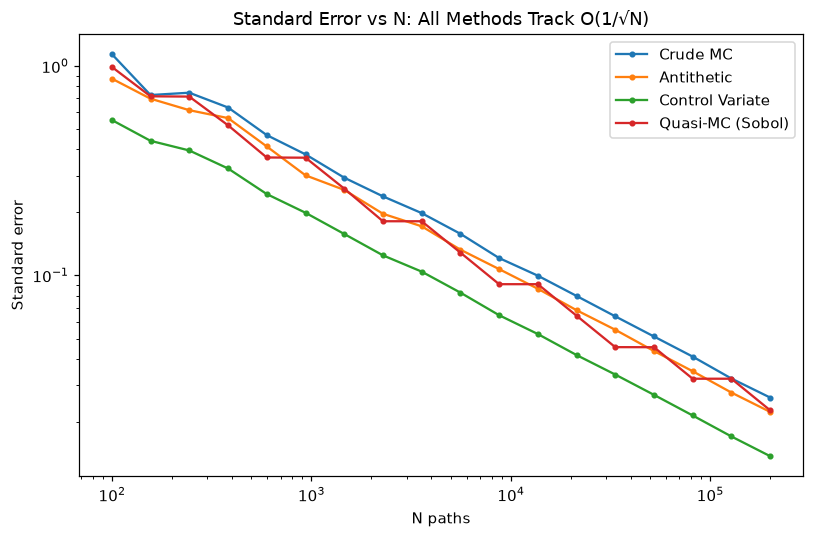

In [10]:
# Plot 9 — standard error convergence across methods
n_list = np.unique(np.logspace(2, 5.3, 18).astype(int))
se_crude, se_anti, se_cv, se_sobol = [], [], [], []
for i, N in enumerate(n_list):
    se_crude.append(mc_price_crude(S0, K, T, r, sigma, N, seed=i)[1])
    se_anti.append(mc_price_antithetic(S0, K, T, r, sigma, N, seed=i)[1])
    se_cv.append(mc_price_control_variate(S0, K, T, r, sigma, N, seed=i)[1])
    se_sobol.append(mc_price_sobol(S0, K, T, r, sigma, N, seed=i)[1])

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.loglog(n_list, se_crude, marker=".", label="Crude MC")
ax.loglog(n_list, se_anti, marker=".", label="Antithetic")
ax.loglog(n_list, se_cv, marker=".", label="Control Variate")
ax.loglog(n_list, se_sobol, marker=".", label="Quasi-MC (Sobol)")
ax.set_xlabel("N paths"); ax.set_ylabel("Standard error")
ax.set_title("Standard Error vs N: All Methods Track O(1/√N)")
ax.legend(); fig.tight_layout()
fig.savefig("../outputs/09_vr_convergence.png", dpi=130)
plt.show()

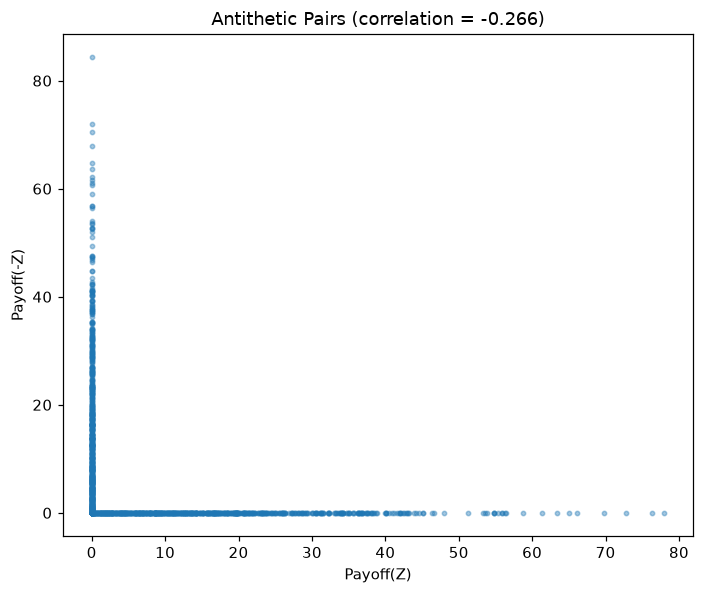

In [11]:
# Plot 10 — antithetic pair scatter
_, _, payoff_pos, payoff_neg = mc_price_antithetic(S0, K, T, r, sigma, 4000, seed=5)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(payoff_pos, payoff_neg, s=8, alpha=0.4)
corr = np.corrcoef(payoff_pos, payoff_neg)[0, 1]
ax.set_xlabel("Payoff(Z)"); ax.set_ylabel("Payoff(-Z)")
ax.set_title(f"Antithetic Pairs (correlation = {corr:.3f})")
fig.tight_layout()
fig.savefig("../outputs/10_antithetic_pairs.png", dpi=130)
plt.show()

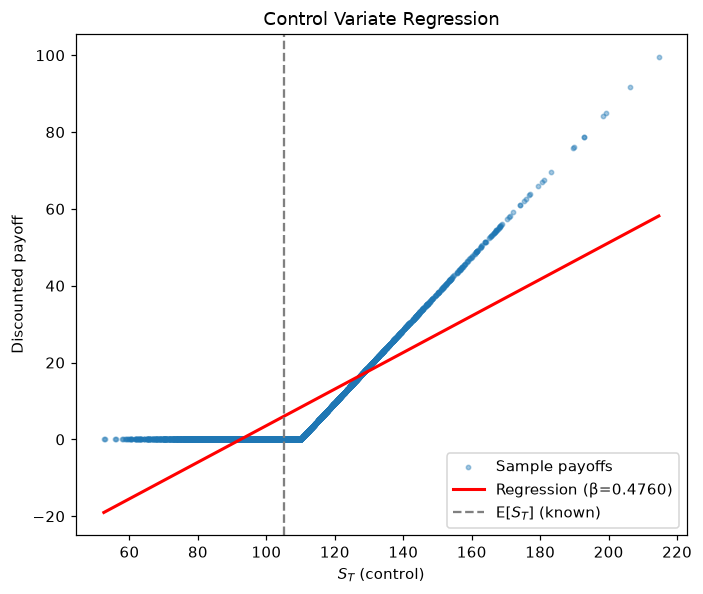

In [12]:
# Plot 11 — control variate regression
rng = np.random.default_rng(6)
Z = rng.standard_normal(4000)
S_T_cv = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
payoff_cv = np.exp(-r*T) * np.maximum(S_T_cv - K, 0.0)
beta = np.cov(payoff_cv, S_T_cv, ddof=1)[0, 1] / np.var(S_T_cv, ddof=1)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(S_T_cv, payoff_cv, s=8, alpha=0.4, label="Sample payoffs")
xs = np.linspace(S_T_cv.min(), S_T_cv.max(), 100)
ax.plot(xs, payoff_cv.mean() + beta*(xs - S_T_cv.mean()), color="red", lw=2,
        label=f"Regression (β={beta:.4f})")
ax.axvline(S0*np.exp(r*T), ls="--", color="gray", label="E[$S_T$] (known)")
ax.set_xlabel("$S_T$ (control)"); ax.set_ylabel("Discounted payoff")
ax.set_title("Control Variate Regression"); ax.legend()
fig.tight_layout()
fig.savefig("../outputs/11_control_variate.png", dpi=130)
plt.show()

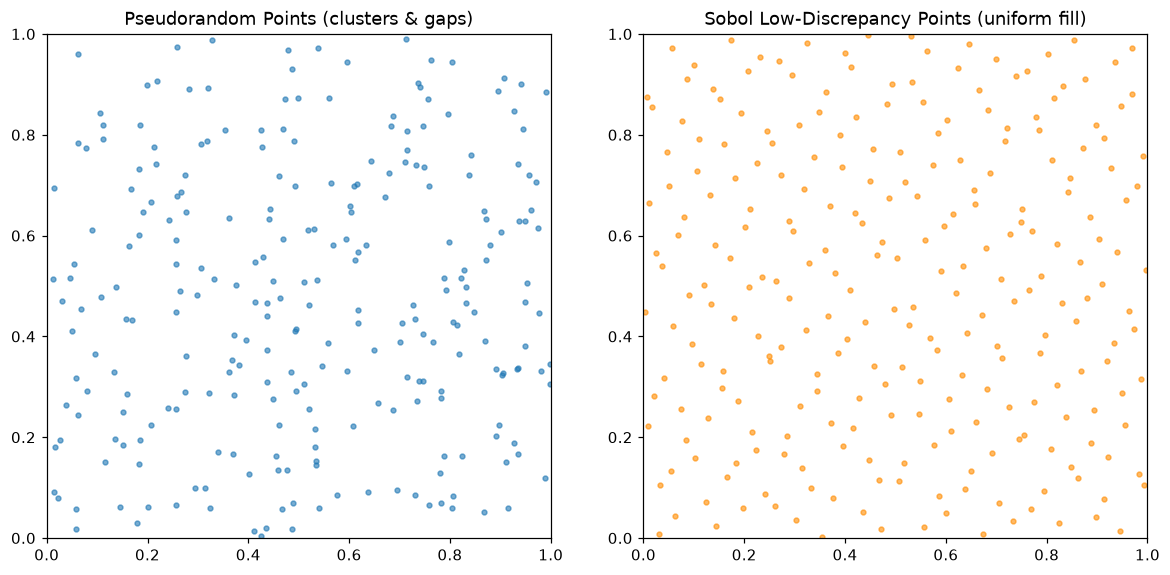

In [13]:
# Plot 12 — Sobol vs pseudorandom point clouds
rng = np.random.default_rng(8)
pseudo = rng.random((256, 2))
sampler = qmc.Sobol(d=2, scramble=True, seed=8)
sobol_pts = sampler.random_base2(m=8)

fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))
axes[0].scatter(pseudo[:,0], pseudo[:,1], s=10, alpha=0.6)
axes[0].set_title("Pseudorandom Points (clusters & gaps)")
axes[1].scatter(sobol_pts[:,0], sobol_pts[:,1], s=10, alpha=0.6, color="darkorange")
axes[1].set_title("Sobol Low-Discrepancy Points (uniform fill)")
for a in axes:
    a.set_xlim(0,1); a.set_ylim(0,1); a.set_aspect("equal")
fig.tight_layout()
fig.savefig("../outputs/12_sobol_vs_pseudo.png", dpi=130)
plt.show()

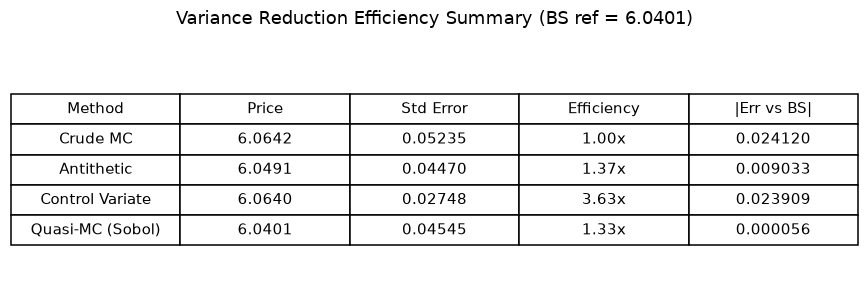

  Crude MC           price=6.0642 se=0.05235 eff=1.00x
  Antithetic         price=6.0491 se=0.04470 eff=1.37x
  Control Variate    price=6.0640 se=0.02748 eff=3.63x
  Quasi-MC (Sobol)   price=6.0401 se=0.04545 eff=1.33x


In [14]:
# Plot 13 — efficiency summary table
rows, bs_ref = efficiency_table(S0, K, T, r, sigma, n_paths=50_000, seed=42)
fig, ax = plt.subplots(figsize=(8, 2.8)); ax.axis("off")
cell_text = [[name, f"{p:.4f}", f"{se:.5f}", f"{eff:.2f}x", f"{err:.6f}"]
             for name, (p, se, eff, err) in rows.items()]
tbl = ax.table(cellText=cell_text,
               colLabels=["Method", "Price", "Std Error", "Efficiency", "|Err vs BS|"],
               loc="center", cellLoc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1, 1.7)
ax.set_title(f"Variance Reduction Efficiency Summary (BS ref = {bs_ref:.4f})", pad=20)
fig.tight_layout()
fig.savefig("../outputs/13_efficiency_summary.png", dpi=130)
plt.show()
for name, (p, se, eff, err) in rows.items():
    print(f"  {name:18s} price={p:.4f} se={se:.5f} eff={eff:.2f}x")

## Phase 4 — Asian & Barrier Options
Path-dependent payoffs that need the full simulated path, not just $S_T$.

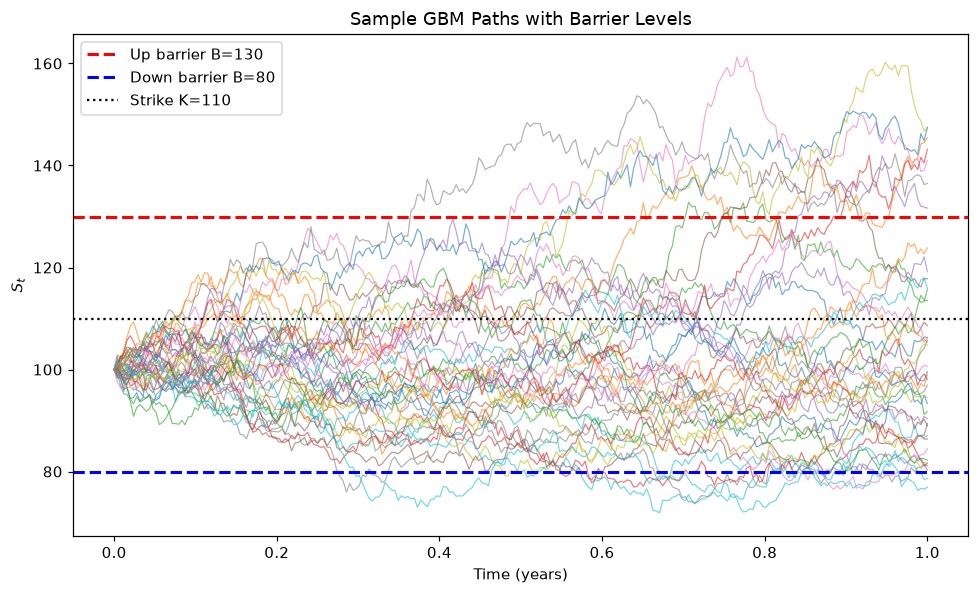

In [15]:
# Plot 14 — sample GBM paths with barrier levels
sample_paths = simulate_paths(S0, r, sigma, T, N_STEPS, 40, seed=3)
fig, ax = plt.subplots(figsize=(9, 5.5))
t_grid = np.linspace(0, T, N_STEPS + 1)
for p in sample_paths:
    ax.plot(t_grid, p, lw=0.8, alpha=0.6)
ax.axhline(B_up, color="red", ls="--", lw=2, label=f"Up barrier B={B_up}")
ax.axhline(B_down, color="blue", ls="--", lw=2, label=f"Down barrier B={B_down}")
ax.axhline(K, color="black", ls=":", lw=1.5, label=f"Strike K={K}")
ax.set_xlabel("Time (years)"); ax.set_ylabel("$S_t$")
ax.set_title("Sample GBM Paths with Barrier Levels"); ax.legend()
fig.tight_layout()
fig.savefig("../outputs/14_gbm_paths_barriers.png", dpi=130)
plt.show()

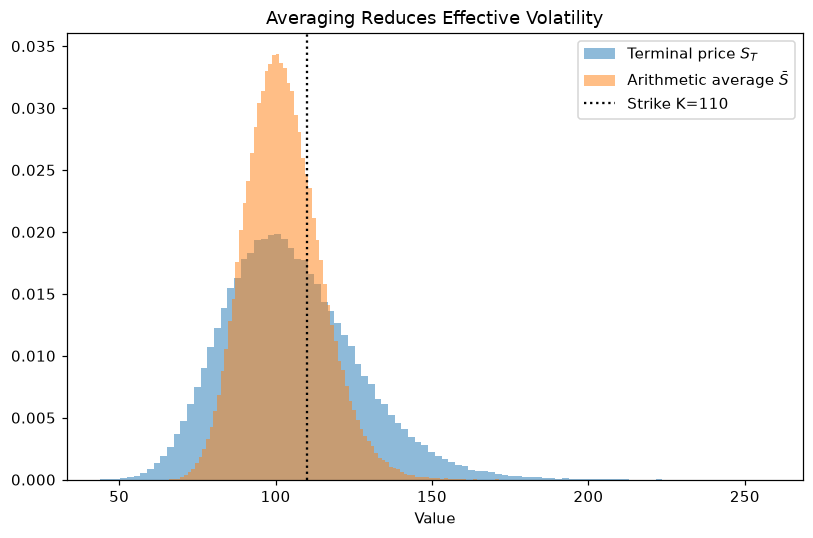

In [16]:
# Plot 15 — Asian averaging effect
paths_full = simulate_paths(S0, r, sigma, T, N_STEPS, N_PATHS, seed=4)
S_T_full = paths_full[:, -1]
arith_avg = paths_full[:, 1:].mean(axis=1)

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.hist(S_T_full, bins=100, density=True, alpha=0.5, label="Terminal price $S_T$")
ax.hist(arith_avg, bins=100, density=True, alpha=0.5, label=r"Arithmetic average $\bar{S}$")
ax.axvline(K, color="black", ls=":", label=f"Strike K={K}")
ax.set_xlabel("Value"); ax.set_title("Averaging Reduces Effective Volatility")
ax.legend(); fig.tight_layout()
fig.savefig("../outputs/15_asian_averaging.png", dpi=130)
plt.show()

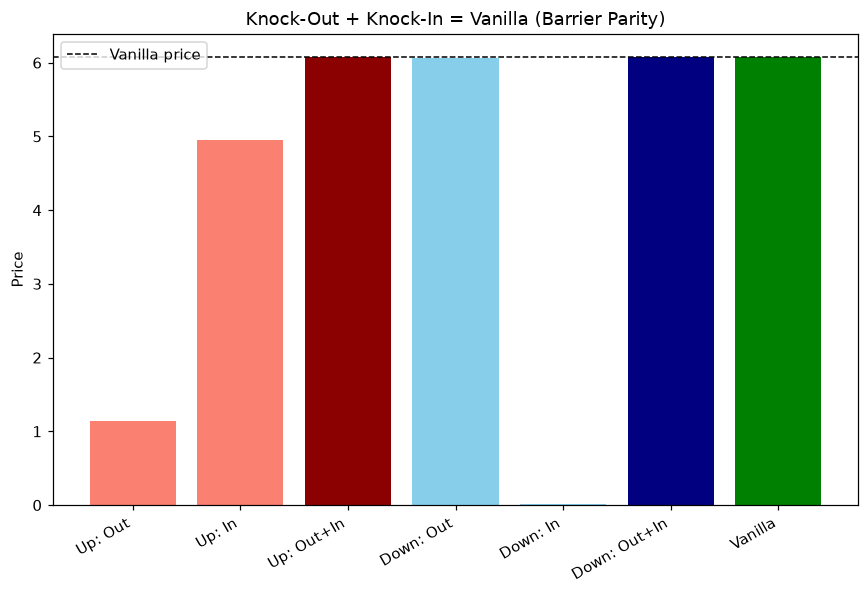

In [17]:
# Plot 16 — barrier in/out parity
out_up, in_up, sum_up, vanilla_up = barrier_parity_check(S0, K, B_up, T, r, sigma, N_STEPS, N_PATHS, side="up", seed=2)
out_dn, in_dn, sum_dn, vanilla_dn = barrier_parity_check(S0, K, B_down, T, r, sigma, N_STEPS, N_PATHS, side="down", seed=2)

fig, ax = plt.subplots(figsize=(8, 5.5))
labels = ["Up: Out", "Up: In", "Up: Out+In", "Down: Out", "Down: In", "Down: Out+In", "Vanilla"]
values = [out_up, in_up, sum_up, out_dn, in_dn, sum_dn, vanilla_up]
colors = ["salmon", "salmon", "darkred", "skyblue", "skyblue", "navy", "green"]
ax.bar(labels, values, color=colors)
ax.axhline(vanilla_up, color="black", ls="--", lw=1, label="Vanilla price")
ax.set_ylabel("Price"); ax.set_title("Knock-Out + Knock-In = Vanilla (Barrier Parity)")
plt.xticks(rotation=30, ha="right"); ax.legend()
fig.tight_layout()
fig.savefig("../outputs/16_barrier_parity.png", dpi=130)
plt.show()

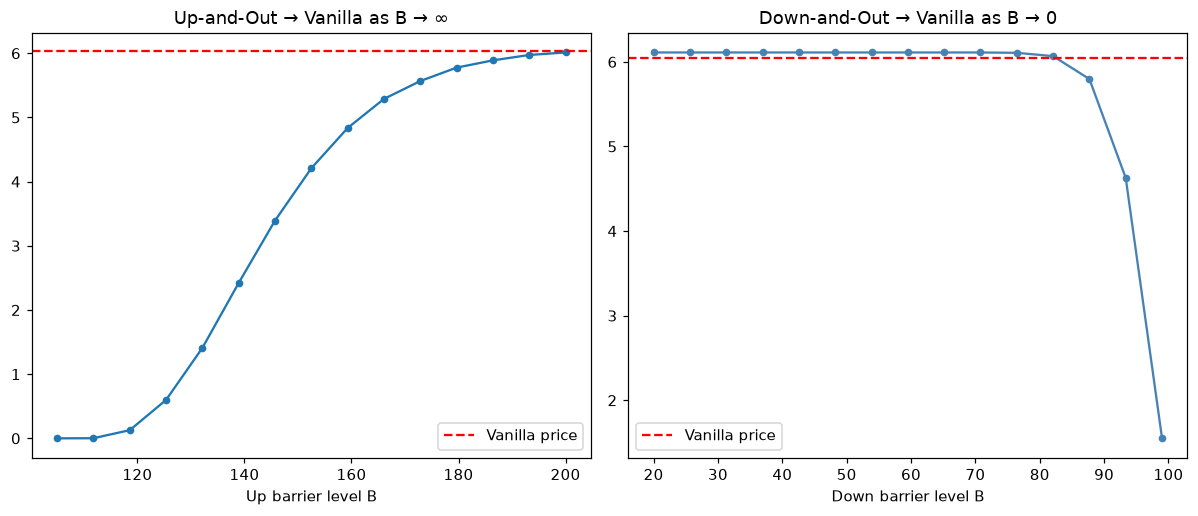

In [18]:
# Plot 17 — barrier sensitivity to barrier level
up_levels = np.linspace(105, 200, 15)
down_levels = np.linspace(20, 99, 15)
uao_prices = [barrier_option_mc(S0, K, b, T, r, sigma, N_STEPS, 60_000, "call", "up-and-out", seed=9)[0] for b in up_levels]
dao_prices = [barrier_option_mc(S0, K, b, T, r, sigma, N_STEPS, 60_000, "call", "down-and-out", seed=9)[0] for b in down_levels]
vanilla = bs_price(S0, K, T, r, sigma)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
axes[0].plot(up_levels, uao_prices, marker="o", ms=4)
axes[0].axhline(vanilla, color="red", ls="--", label="Vanilla price")
axes[0].set_xlabel("Up barrier level B"); axes[0].set_title("Up-and-Out → Vanilla as B → ∞")
axes[0].legend()
axes[1].plot(down_levels, dao_prices, marker="o", ms=4, color="steelblue")
axes[1].axhline(vanilla, color="red", ls="--", label="Vanilla price")
axes[1].set_xlabel("Down barrier level B"); axes[1].set_title("Down-and-Out → Vanilla as B → 0")
axes[1].legend(); fig.tight_layout()
fig.savefig("../outputs/17_barrier_sensitivity.png", dpi=130)
plt.show()

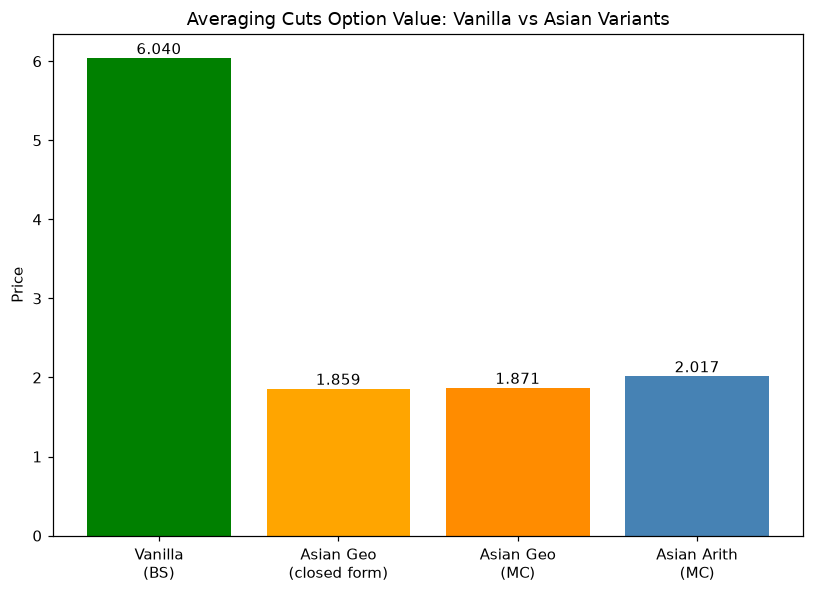

Up barrier parity:   out=1.1338 in=4.9487 sum=6.0824 vanilla=6.0824
Down barrier parity: out=6.0611 in=0.0213 sum=6.0824 vanilla=6.0824


In [19]:
# Plot 18 — Asian price comparison
arith_price, arith_se = asian_arithmetic_mc(S0, K, T, r, sigma, N_STEPS, N_PATHS, seed=1)
geo_mc_price, geo_se = asian_geometric_mc(S0, K, T, r, sigma, N_STEPS, N_PATHS, seed=1)
geo_cf_price = asian_geometric_closed_form(S0, K, T, r, sigma, N_STEPS)
vanilla_price = bs_price(S0, K, T, r, sigma)

fig, ax = plt.subplots(figsize=(7.5, 5.5))
names = ["Vanilla\n(BS)", "Asian Geo\n(closed form)", "Asian Geo\n(MC)", "Asian Arith\n(MC)"]
vals = [vanilla_price, geo_cf_price, geo_mc_price, arith_price]
bars = ax.bar(names, vals, color=["green", "orange", "darkorange", "steelblue"])
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.05, f"{v:.3f}", ha="center")
ax.set_ylabel("Price"); ax.set_title("Averaging Cuts Option Value: Vanilla vs Asian Variants")
fig.tight_layout()
fig.savefig("../outputs/18_asian_analysis.png", dpi=130)
plt.show()

print(f"Up barrier parity:   out={out_up:.4f} in={in_up:.4f} sum={sum_up:.4f} vanilla={vanilla_up:.4f}")
print(f"Down barrier parity: out={out_dn:.4f} in={in_dn:.4f} sum={sum_dn:.4f} vanilla={vanilla_dn:.4f}")

## Phase 5 — Heston Stochastic Volatility (Capstone)

Replaces the constant σ assumption with a second mean-reverting SDE for
variance itself — the same OU-style structure from the original
coursework, now driving the volatility that feeds into GBM. Calibrated so
`v0 = theta = 0.20²`, matching the constant-vol case used everywhere above,
with `rho = -0.7` (the empirical "leverage effect": falling prices coincide
with rising volatility).

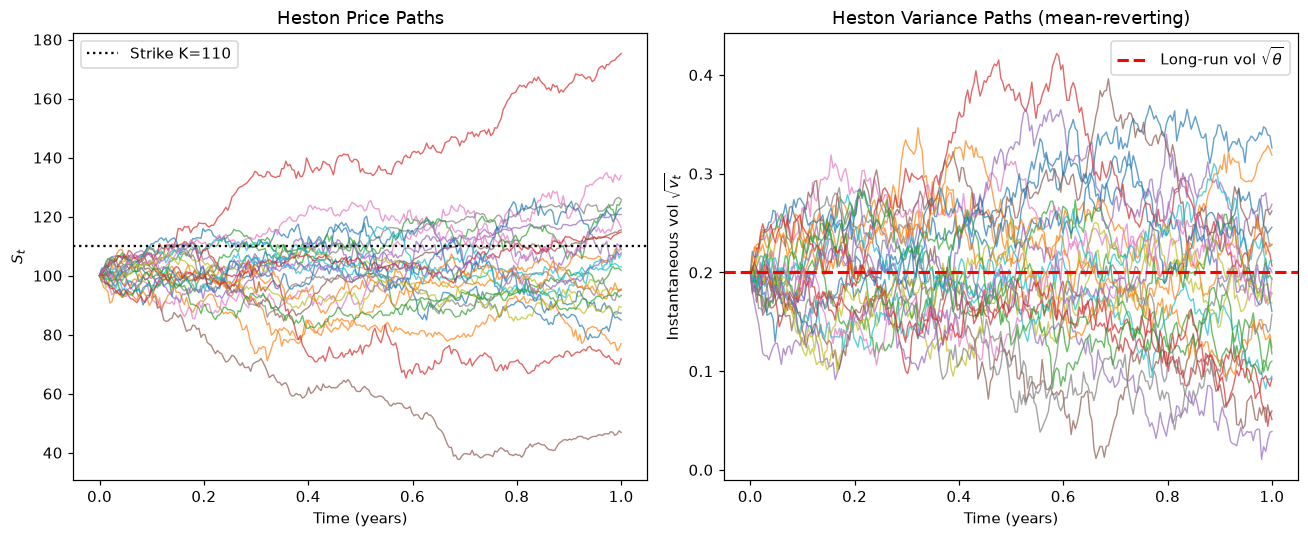

In [20]:
v0, kappa, theta_v, xi, rho = sigma**2, 2.0, sigma**2, 0.30, -0.7

# Plot 19 — sample price & variance paths under Heston
S_h, v_h = simulate_heston_paths(S0, v0, r, kappa, theta_v, xi, rho, T, N_STEPS, 25, seed=15)
t_grid = np.linspace(0, T, N_STEPS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for p in S_h:
    axes[0].plot(t_grid, p, lw=0.9, alpha=0.7)
axes[0].axhline(K, color="black", ls=":", label=f"Strike K={K}")
axes[0].set_xlabel("Time (years)"); axes[0].set_ylabel("$S_t$")
axes[0].set_title("Heston Price Paths"); axes[0].legend()

for v_path in np.sqrt(np.maximum(v_h, 0)):
    axes[1].plot(t_grid, v_path, lw=0.9, alpha=0.7)
axes[1].axhline(np.sqrt(theta_v), color="red", ls="--", lw=2, label=r"Long-run vol $\sqrt{\theta}$")
axes[1].set_xlabel("Time (years)"); axes[1].set_ylabel(r"Instantaneous vol $\sqrt{v_t}$")
axes[1].set_title("Heston Variance Paths (mean-reverting)"); axes[1].legend()
fig.tight_layout()
fig.savefig("../outputs/19_heston_paths.png", dpi=130)
plt.show()

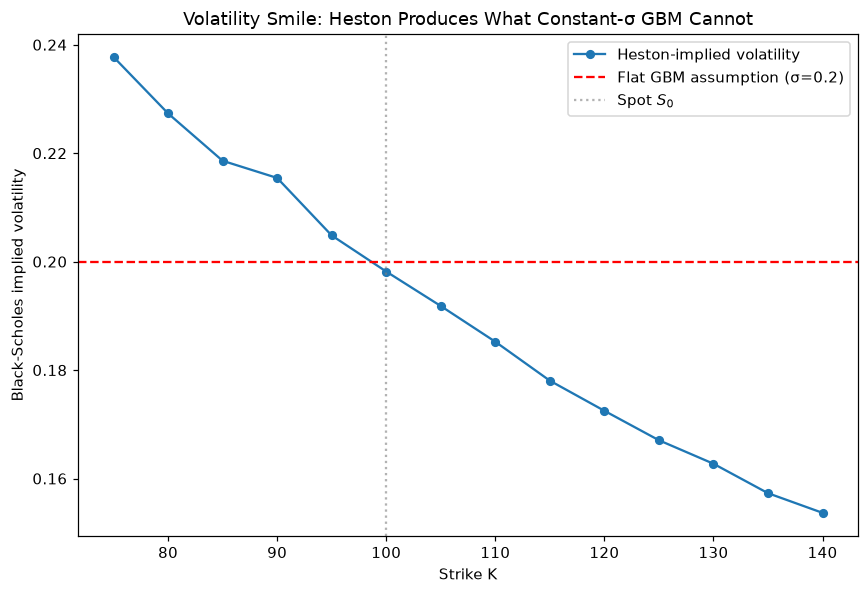

Heston price @ K=110: 5.4478  |  BS flat-vol price: 6.0401
Heston implied vol @ K=110: 0.1850  (input flat σ = 0.2)


In [21]:
# Plot 20 — implied volatility smile: Heston vs flat GBM assumption
strikes = np.linspace(75, 140, 14)
prices, ivs = implied_vol_smile(S0, T, r, v0, kappa, theta_v, xi, rho,
                                  N_STEPS, 120_000, strikes, seed=300)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(strikes, ivs, marker="o", ms=5, label="Heston-implied volatility")
ax.axhline(sigma, color="red", ls="--", label=f"Flat GBM assumption (σ={sigma})")
ax.axvline(S0, color="gray", ls=":", alpha=0.6, label="Spot $S_0$")
ax.set_xlabel("Strike K"); ax.set_ylabel("Black-Scholes implied volatility")
ax.set_title("Volatility Smile: Heston Produces What Constant-σ GBM Cannot")
ax.legend(); fig.tight_layout()
fig.savefig("../outputs/20_implied_vol_smile.png", dpi=130)
plt.show()

heston_price_atm, _ = heston_mc_price(S0, K, T, r, v0, kappa, theta_v, xi, rho, N_STEPS, N_PATHS, seed=42)
print(f"Heston price @ K={K}: {heston_price_atm:.4f}  |  BS flat-vol price: {bs_price(S0,K,T,r,sigma):.4f}")
print(f"Heston implied vol @ K={K}: {implied_vol(heston_price_atm, S0, K, T, r):.4f}  (input flat σ = {sigma})")

## Summary

| Phase | What it shows |
|---|---|
| 1 | MC engine validated against closed-form Black-Scholes |
| 2 | Finite-difference Greeks match analytical Greeks to <1% |
| 3 | Variance reduction: Control Variate gives ~3.6x efficiency, Sobol QMC gives near-exact pricing |
| 4 | Path-dependent Asian/Barrier pricing, with exact in/out parity verification |
| 5 | Heston stochastic volatility reproduces the implied volatility smile that constant-σ GBM structurally cannot |

All 20 figures are saved to `../outputs/`.